# Разработка A/B-тестирования и анализ результатов

Мы работаем продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В нашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Нас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Мы будем работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


Наши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
sessions_history = pd.read_csv('Desktop/sessions_project_history.csv')
sessions_history.head(5)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [3]:
sessions_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


#### 1.2. Знакомство с данными

In [4]:
sessions_count = sessions_history.groupby('user_id')['session_id'].nunique()
sessions_count

user_id
00005FB6A13A6FBE    2
0000B15A18D77ED9    3
0000C4E3A4A571A9    2
000293FAF9E67A81    4
00029C5AE889A6C3    2
                   ..
FFFCDE7746148710    4
FFFDD413285E753F    3
FFFECBA0F2578AB0    2
FFFEDB68228B5F21    5
FFFF4228DF580C3B    3
Name: session_id, Length: 134039, dtype: int64

In [5]:
sessions_user_max = sessions_count.idxmax()
print(f'Идентификатор пользователя с наибольшим количеством уникальных сессий: {sessions_user_max}') #Выводим на экран идентификатор пользователя с самым большим числом сессий 

sessions_max = sessions_count.max()
print(f'Количество уникальных сессий у такого пользователя: {sessions_max}') #Выводим на экран количество сессий у такого пользователя

user_max_data = sessions_history[sessions_history['user_id'] == sessions_user_max]
user_max_data #Выводим всю информацию о таком пользователе 

Идентификатор пользователя с наибольшим количеством уникальных сессий: 10E0DEFC1ABDBBE0
Количество уникальных сессий у такого пользователя: 10


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, нам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

In [6]:
#Расчет уникальных пользователей
unique_users = sessions_history.groupby('session_date')['user_id'].nunique()

#Расчет зарегистрированных пользователей
registration_users = sessions_history[sessions_history['registration_flag'] == 1].groupby('session_date')['user_id'].nunique()

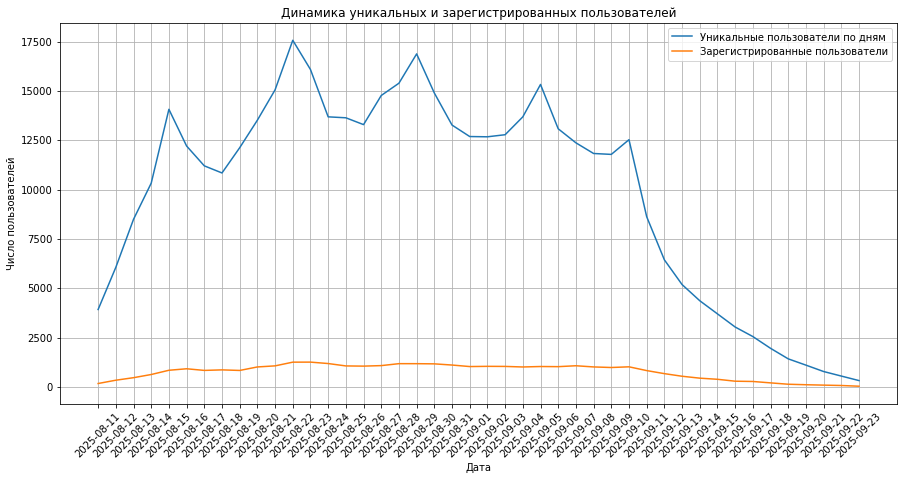

In [7]:
#Строим 2 графика на одной фигуре (уникальные и зарегистрированные пользователи)
plt.figure(figsize=(15, 7))
plt.plot(unique_users, label='Уникальные пользователи по дням')
plt.plot(registration_users, label='Зарегистрированные пользователи')
plt.title('Динамика уникальных и зарегистрированных пользователей')
plt.xlabel('Дата')
plt.ylabel('Число пользователей')
plt.grid()
plt.legend()
plt.xticks(rotation=45)
plt.show()

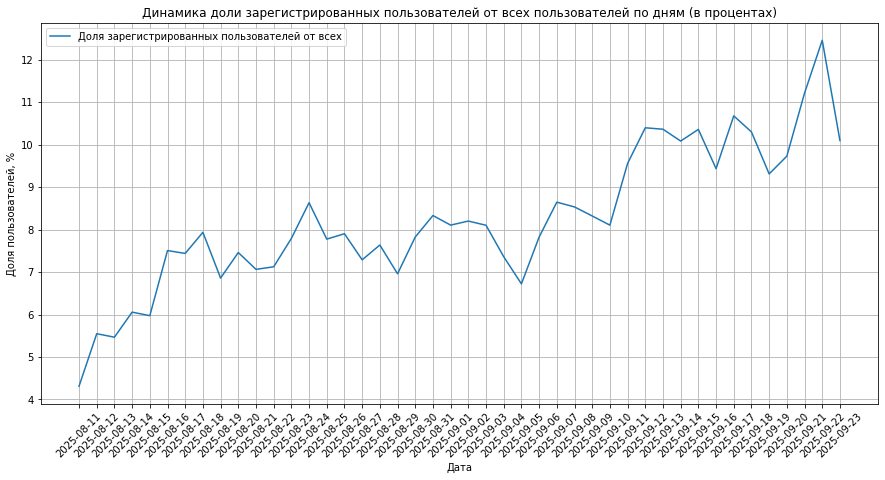

In [8]:
#Строим график доли зарегистрированных пользователей
share_reg = 100 * registration_users / unique_users
plt.figure(figsize=(15, 7))
plt.plot(share_reg, label='Доля зарегистрированных пользователей от всех')
plt.title('Динамика доли зарегистрированных пользователей от всех пользователей по дням (в процентах)')
plt.xlabel('Дата')
plt.ylabel('Доля пользователей, %')
plt.grid()
plt.legend()
plt.xticks(rotation=45)
plt.show()

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируем число просмотренных страниц во время первых сессий пользователей. Найдем количество первых сессий для каждого значения количества просмотренных страниц.

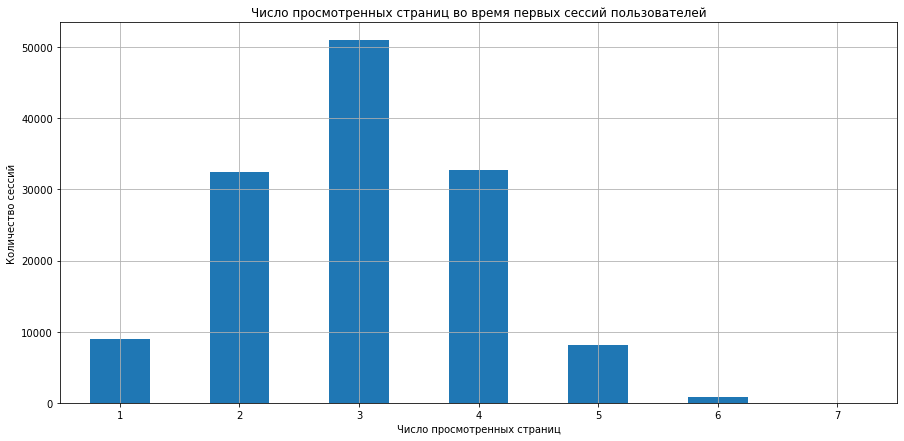

In [9]:
#Подсчет числа первых сессий для каждого значения просмотренных страниц
pages_in_first_session = sessions_history[sessions_history['session_number'] == 1].groupby('page_counter')['session_id'].count()

#Строим график
plt.figure(figsize=(15, 7))
pages_in_first_session.plot(kind='bar')
plt.title('Число просмотренных страниц во время первых сессий пользователей')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.grid()
plt.xticks(rotation=0)
plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

In [11]:
# Функция, создающая бинарный столбец 'good_session'
def is_good_session(pages):
    return 1 if pages >= 4 else 0

# Применяем эту функцию
sessions_history['good_session'] = sessions_history['page_counter'].apply(is_good_session)

# Считаем метрику
share_good_sessions = sessions_history[sessions_history['session_number'] == 1].groupby('session_date')['good_session'].mean()
share_good_sessions

session_date
2025-08-11    0.312835
2025-08-12    0.298344
2025-08-13    0.306861
2025-08-14    0.319098
2025-08-15    0.311114
2025-08-16    0.308424
2025-08-17    0.319342
2025-08-18    0.313089
2025-08-19    0.314370
2025-08-20    0.309108
2025-08-21    0.309002
2025-08-22    0.309504
2025-08-23    0.302132
2025-08-24    0.316413
2025-08-25    0.306655
2025-08-26    0.318169
2025-08-27    0.314706
2025-08-28    0.314280
2025-08-29    0.313664
2025-08-30    0.310680
2025-08-31    0.305928
2025-09-01    0.331788
2025-09-02    0.315123
2025-09-03    0.310181
2025-09-04    0.309962
2025-09-05    0.299613
2025-09-06    0.315618
2025-09-07    0.310791
2025-09-08    0.301741
2025-09-09    0.297384
2025-09-10    0.310047
Name: good_session, dtype: float64

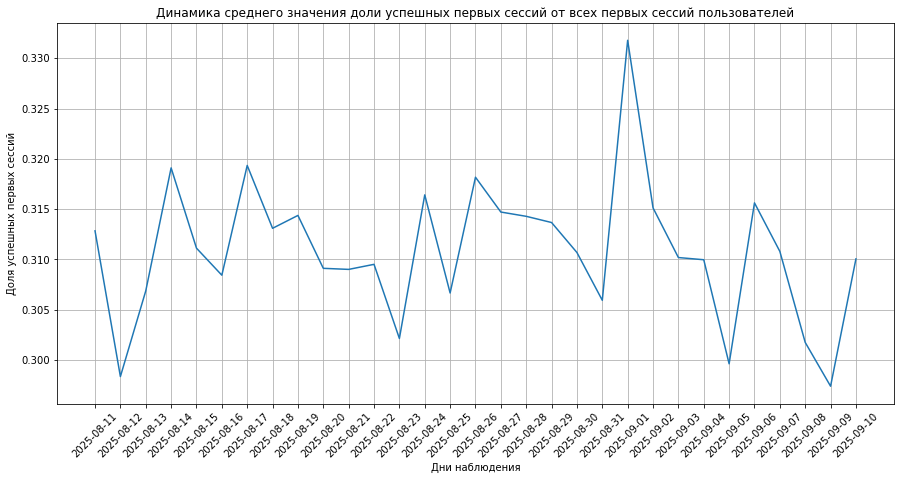

In [12]:
# Создаем график динамики среднего значения доли успешных первых сессий
plt.figure(figsize=(15, 7))
plt.plot(share_good_sessions)
plt.title('Динамика среднего значения доли успешных первых сессий от всех первых сессий пользователей')
plt.xlabel('Дни наблюдения')
plt.ylabel('Доля успешных первых сессий')
plt.grid()
plt.xticks(rotation=45)
plt.show()

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
При расчёте размера выборки используем метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

In [13]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = p * 0.03 # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

In [14]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровне трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровне трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие нас метрики корректно считаются.

Группа A: 1477 пользователей
Группа B: 1466 пользователей
Процентная разница: 0.74%


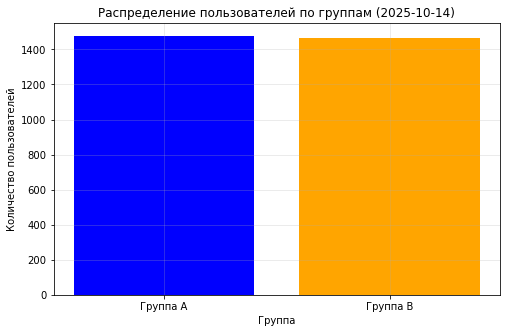

In [16]:
sessions_test_part = pd.read_csv('Desktop/sessions_project_test_part.csv')

first_day = sessions_test_part['session_date'].min()
data_one_day = sessions_test_part[sessions_test_part['session_date'] == first_day]

# Считаем пользователей по группам
users_a = data_one_day[data_one_day['test_group'] == 'A']['user_id'].nunique()
users_b = data_one_day[data_one_day['test_group'] == 'B']['user_id'].nunique()

# Процентная разница
percent_diff = 100 * abs(users_a - users_b) / users_a

print(f'Группа A: {users_a} пользователей')
print(f'Группа B: {users_b} пользователей')
print(f'Процентная разница: {percent_diff:.2f}%')

# График
plt.figure(figsize=(8, 5))
plt.bar(['Группа A', 'Группа B'], [users_a, users_b], color=['blue', 'orange'])
plt.title(f'Распределение пользователей по группам ({first_day})')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')
plt.grid(True, alpha=0.3)
plt.show()

#### 3.2. Проверка пересечений пользователей

In [17]:
users_a = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].unique())

users_b = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].unique())

intersection = users_a.intersection(users_b)

print(f'Пользователей в обеих группах: {len(intersection)}')

if len(intersection) == 0:
    print('Пересечений нет, группы независимы')
else:
    print(f'Найдены пересечения, пользователи: {intersection}')

Пользователей в обеих группах: 0
Пересечений нет, группы независимы


#### 3.3. Равномерность разделения пользователей по устройствам

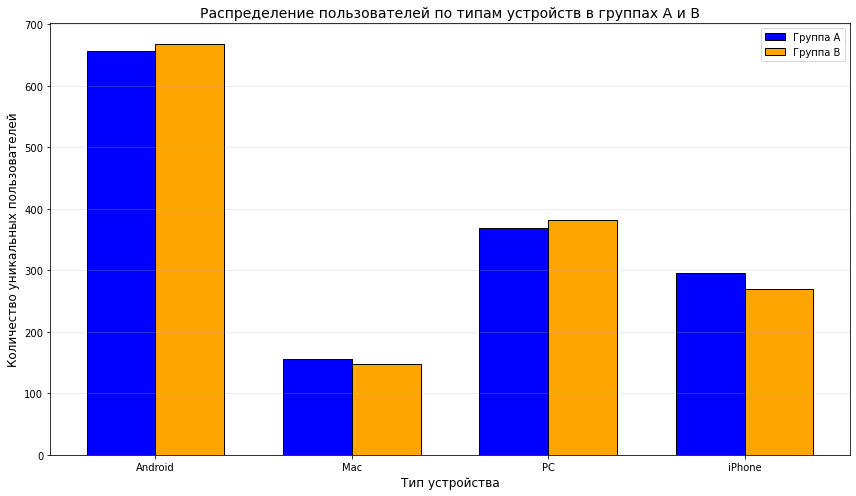

In [18]:
import numpy as np

# Делим пользователей по группам
devices_A = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('device')['user_id'].nunique()
devices_B = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('device')['user_id'].nunique()

devices_compare = pd.DataFrame({
    'Группа A': devices_A,
    'Группа B': devices_B
})

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(devices_compare.index))
width = 0.35

bars1 = ax.bar(x - width/2, devices_compare['Группа A'], width, label='Группа A', color='blue', edgecolor='black')
bars2 = ax.bar(x + width/2, devices_compare['Группа B'], width, label='Группа B', color='orange', edgecolor='black')

ax.set_xlabel('Тип устройства', fontsize=12)
ax.set_ylabel('Количество уникальных пользователей', fontsize=12)
ax.set_title('Распределение пользователей по типам устройств в группах A и B', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(devices_compare.index)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам

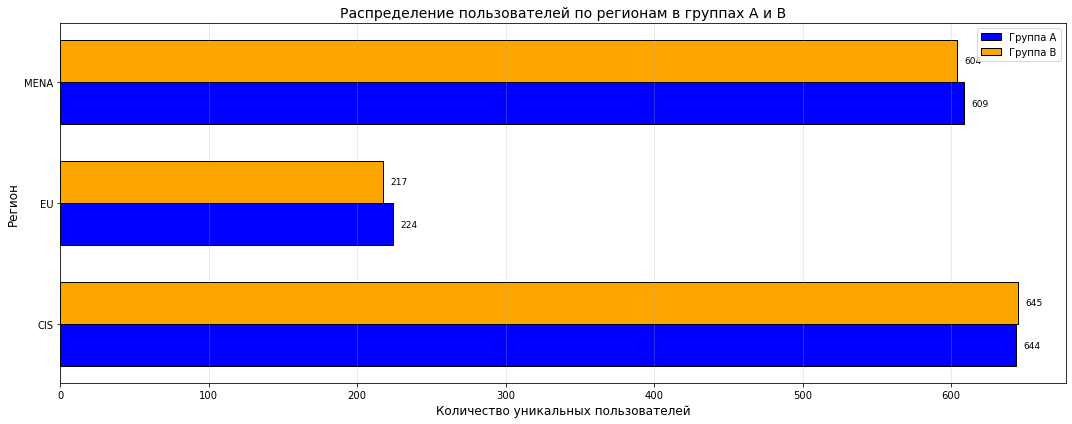

In [19]:
# Делим пользователей по группам
region_A = sessions_test_part[sessions_test_part['test_group'] == 'A'].groupby('region')['user_id'].nunique()
region_B = sessions_test_part[sessions_test_part['test_group'] == 'B'].groupby('region')['user_id'].nunique()

region_compare = pd.DataFrame({
    'Группа A': region_A,
    'Группа B': region_B
})

fig, ax = plt.subplots(figsize=(15, 6))

y = np.arange(len(region_compare.index))
height = 0.35

bars1 = ax.barh(y - height/2, region_compare['Группа A'], height, label='Группа A', color='blue', edgecolor='black')
bars2 = ax.barh(y + height/2, region_compare['Группа B'], height, label='Группа B', color='orange', edgecolor='black')

ax.set_xlabel('Количество уникальных пользователей', fontsize=12)
ax.set_ylabel('Регион', fontsize=12)
ax.set_title('Распределение пользователей по регионам в группах A и B', fontsize=14)
ax.set_yticks(y)
ax.set_yticklabels(region_compare.index)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='x')

for bar in bars1:
    width = bar.get_width()
    ax.text(width + 5, bar.get_y() + bar.get_height()/2,
            f'{int(width)}', ha='left', va='center', fontsize=9)

for bar in bars2:
    width = bar.get_width()
    ax.text(width + 5, bar.get_y() + bar.get_height()/2,
            f'{int(width)}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста можно сделать несколько важных выводов:
- Было обнаружено незначительное различие в количестве пользователей в 2 группах: в группе A оказалось на 11 человек больше, чем в группе B (1477 против 1466). При этом процентная разница составила всего 0.74%, что мало и таким различием можно пренебречь.
- Пересечений найдено не было, а значит выборки полностью независимы и пригодны к проведению A/B-теста.
- Для тестовой и контрольной групп по категориальным переменным - устройствам и регионам - сохраняется равномерное распределение: группы очень близки по количеству уникальных пользователей в каждом типе устройств и регионе.

Итог: эксперимент можно продолжать, пользователи распределены равномерно, данные независимы и сопоставимы по количеству пользователей в каждой группе.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

In [21]:
sessions_test = pd.read_csv('Desktop/sessions_project_test.csv')

# Применяем функцию, создающую бинарный столбец 'good_session'
sessions_test['good_session'] = sessions_test['page_counter'].apply(is_good_session)

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик

- Нулевая гипотеза H0: новый алгоритм рекомендаций не влияет на долю успешных первых сессий пользователей (p_A = p_B).

- Альтернативная гипотеза H1: новый алгоритм рекомендаций увеличивает долю успешных первых сессий пользователей (p_A < p_B).

Целевая метрика: доля успешных первых сессий.

Прокси-метрика: среднее количество просмотренных страниц за сессию (коррелирует с целевой и отражает интерес пользователей).

Барьерная метрика: средняя длительность сессии пользователя (алгоритм не должен ухудшать базовый пользовательский опыт, если время, проведенное в приложении, меньше установленного уровня - изменения делают только хуже).

#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

In [22]:
# Расчет показателей
primary_metric_A = sessions_test[(sessions_test['test_group'] == 'A') & (sessions_test['session_number'] == 1)]['good_session'].mean()
primary_metric_B = sessions_test[(sessions_test['test_group'] == 'B') & (sessions_test['session_number'] == 1)]['good_session'].mean()
diff_metrics = primary_metric_A - primary_metric_B

# Выод на экран
print(f'Доля успешных первых сессий для группы A (целевая метрика): {primary_metric_A}')
print(f'Доля успешных первых сессий для группы B (целевая метрика): {primary_metric_B}')
print(f'Разница метрик: {diff_metrics}')

Доля успешных первых сессий для группы A (целевая метрика): 0.31572351932462733
Доля успешных первых сессий для группы B (целевая метрика): 0.3146730669434354
Разница метрик: 0.0010504523811919464


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

In [23]:
# ПОДГОТОВКА К ТЕСТУ
# Размеры выборок
n_a = sessions_test[(sessions_test['test_group'] == 'A') & (sessions_test['session_number'] == 1)]['user_id'].nunique()
n_b = sessions_test[(sessions_test['test_group'] == 'B') & (sessions_test['session_number'] == 1)]['user_id'].nunique()

# Количество успехов в каждой выборке (просмотров нужного количества страниц в первую сессию)
m_a = sessions_test[(sessions_test['test_group'] == 'A') & (sessions_test['session_number'] == 1) & (sessions_test['good_session'] == 1)]['user_id'].nunique()
m_b = sessions_test[(sessions_test['test_group'] == 'B') & (sessions_test['session_number'] == 1) & (sessions_test['good_session'] == 1)]['user_id'].nunique()

# Доли успехов для каждой группы
p_a, p_b = m_a/n_a, m_b/n_b

# Проверяем предпосылки о достаточном количестве данных
if (p_a*n_a > 10) and ((1-p_a)*n_a > 10) and (p_b*n_b > 10) and ((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else: 
    print('Предпосылка о7 достаточном количестве данных не выполняется!')

Предпосылка о достаточном количестве данных выполняется!


In [24]:
# ПРОВЕДЕНИЕ ТЕСТА
from statsmodels.stats.proportion import proportions_ztest
alpha = 0.05
stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller'
)

print(p_value_ztest)

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза не отвергается')
else: 
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза отвергается')

0.5783523649187868
pvalue=0.5783523649187868 > 0.05
Нулевая гипотеза не отвергается


#### 4.5. Вывод по результатам A/B-эксперимента

- Характеристики эксперимента следующие: уровень значимости был выбран 0.05, ошибка второго рода 0.2, мощность теста 0.8, базовый уровень доли 0.3, а минимальный детектируемый эффект 0.03. В контрольной группе (A) задействованно 15162 пользователя, в тестовой группе (B) 15416 пользователей; рассчетная длительность теста составила 9 дней, фактическая же 20 дней.


- Новый алгоритм, призванный увеличить вовлеченность пользователей в развлекательное приложение, вопреки ожиданиям не смог существенно и статистически значимо повлиять на активность юзеров (долю сессий с просмотрами 4+ страниц). По этой причине нововведение не повлияло на рост ключевой метрики.


- Значение p-value получилось равным примерно 0.578, что больше заданного уровня значимости.


- Внедрять изменение не стоит, статистический z-тест пропорций показал несостоятельность алгоритма, p-value оказался больше уровня значимости, что говорит и принятии нами нулевой гипотезы о равенстве ключевой метрики в контрольной и тестовой группах.